### Data collection

In [1]:
from relife.datasets import load_circuit_breaker

In [2]:
import pandas as pd

lifetime_dataset = load_circuit_breaker()
display(lifetime_dataset)

array([(34.,  True, 33.), (28.,  True, 27.), (12.,  True, 11.), ...,
       (42., False, 31.), (42., False, 31.), (37., False, 26.)],
      shape=(4204,), dtype=[('time', '<f8'), ('event', '?'), ('entry', '<f8')])

Datasets are Numpy structured arrays. Here, the array has 3 fields : time (float), event (bool) and entry (float).

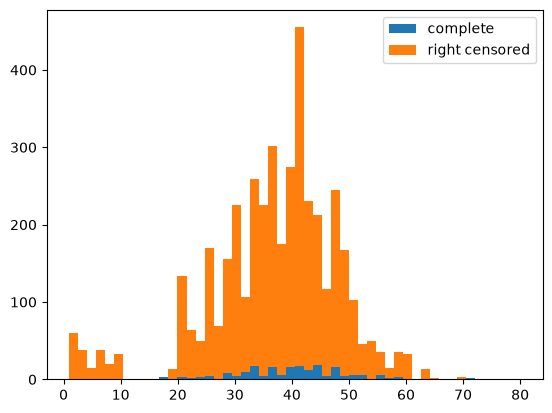

In [3]:
import matplotlib.pyplot as plt

event = lifetime_dataset["event"]

plt.hist(
    [lifetime_dataset["time"][event == True], lifetime_dataset["time"][event == False]],
    bins=50,
    histtype="barstacked",
    label=["complete", "right censored"],
)
plt.legend()
plt.show()

### Lifetime model estimation

We want to estimate the probability that the asset will be functionning beyond time $t$. This information is given by the survival function [1] :

$$
S(t) = P(X > t)
$$

$X$ : the lifetime of the asset (random variable)

In [4]:
from relife.lifetime_models import Weibull, Gompertz, LogLogistic, Exponential

In [5]:
weibull = Weibull()
weibull.fit(
    lifetime_dataset["time"],
    event=lifetime_dataset["event"],
    entry=lifetime_dataset["entry"],
)
print(weibull.get_params())

[3.7267452  0.01232326]


In [6]:
gompertz = Gompertz()
gompertz.fit(
    lifetime_dataset["time"],
    event=lifetime_dataset["event"],
    entry=lifetime_dataset["entry"],
)
print(gompertz.get_params())

[0.00390781 0.07579546]


In [7]:
loglogistic = LogLogistic()
loglogistic.fit(
    lifetime_dataset["time"],
    event=lifetime_dataset["event"],
    entry=lifetime_dataset["entry"],
)
print(loglogistic.get_params())

[3.92211849 0.0128701 ]


In [8]:
exponential = Exponential()
exponential.fit(
    lifetime_dataset["time"],
    event=lifetime_dataset["event"],
    entry=lifetime_dataset["entry"],
)
print(exponential.get_params())

[0.00463636]


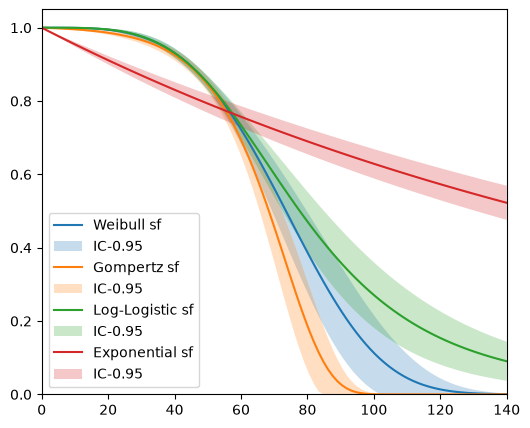

In [9]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(6, 5), dpi=100)

timeline = np.linspace(0, 140, 100)
weibull.plot("sf", timeline, label="Weibull sf", ax=ax)
gompertz.plot("sf", timeline, label="Gompertz sf", ax=ax)
loglogistic.plot("sf", timeline, label="Log-Logistic sf", ax=ax)
exponential.plot("sf", timeline, label="Exponential sf", ax=ax)

plt.legend()
plt.show()

### How to choose the best parametric model ?

In [10]:
print(gompertz.fitting_results)

fitted params : [0.00390781, 0.0757955]
AIC           : 2485.57
AICc          : 2485.57
BIC           : 2498.25


In [11]:
print(weibull.fitting_results)

fitted params : [3.72675, 0.0123233]
AIC           : 2493.72
AICc          : 2493.72
BIC           : 2506.41


In [12]:
print(loglogistic.fitting_results)

fitted params : [3.92212, 0.0128701]
AIC           : 2497.81
AICc          : 2497.81
BIC           : 2510.49


In [13]:
print(exponential.fitting_results)

fitted params : [0.00463636]
AIC           : 2602.52
AICc          : 2602.52
BIC           : 2608.86


Best model minimizes the AIC. Here Gompertz is selected


### Evaluate the performance of maintenance policies

Let's compare two maintenance policies : 

- corrective replacement, *aka* Run-To-Failure (RTF)
- Preventive Age Replacement (PAR)

Cost structure :

- cost of a preventive replacement : $c_p = 300$ k€ 
- cost of a replacement on failure : $c_f = 1100$ k€

In [14]:
cp = 300  # k€, cost of preventive replacement
cf = 1100  # k€, cost of failure
discounting_rate = 0.04

### Creating a Run-To-Failure policy

ReLife has a module called policy that contains all the maintenance policy constructors

In [15]:
from relife.policies import RunToFailurePolicy

rtf_policy = RunToFailurePolicy(gompertz)

In [16]:
rtf_asymtotic_cost = rtf_policy.asymptotic_expected_equivalent_annual_cost(
    cf=cf, discounting_rate=discounting_rate
)
print(
    "Asymptotic expected equivalent annual cost for RTF :",
    round(rtf_asymtotic_cost, 2),
    "k€",
)

Asymptotic expected equivalent annual cost for RTF : 4.49 k€


### Creating a preventive age replacement policy

In [17]:
from relife.policies import AgeReplacementPolicy

par_policy = AgeReplacementPolicy(
    gompertz,
)

In [18]:
optimal_ar = par_policy.compute_optimal_ar(
    cf=cf, cp=cp, discounting_rate=discounting_rate
)
print("Optimal preventive age of replacement :", round(optimal_ar, 2))
print(
    "Cost for optimal ar :",
    round(
        par_policy.asymptotic_expected_equivalent_annual_cost(
            ar=optimal_ar, cf=cf, cp=cp, discounting_rate=discounting_rate
        ),
        2,
    ),
    "k€",
)

Optimal preventive age of replacement : 55.22
Cost for optimal ar : 3.57 k€


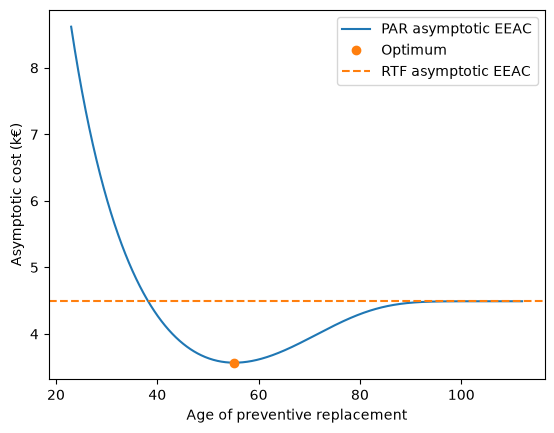

In [19]:
import numpy as np

ar_range = np.linspace(23, 112, 1000)
plt.plot(
    ar_range,
    par_policy.asymptotic_expected_equivalent_annual_cost(
        ar=ar_range, cf=cf, cp=cp, discounting_rate=discounting_rate
    ),
    label="PAR asymptotic EEAC",
)
plt.plot(
    optimal_ar,
    par_policy.asymptotic_expected_equivalent_annual_cost(
        ar=optimal_ar, cf=cf, cp=cp, discounting_rate=discounting_rate
    ),
    "o",
    label="Optimum",
)
plt.axhline(
    rtf_asymtotic_cost, label="RTF asymptotic EEAC", color="C1", linestyle="dashed"
)

plt.xlabel("Age of preventive replacement")
plt.ylabel("Asymptotic cost (k€)")
plt.legend()
plt.show()

The best policy is the cheapest : **preventive age replacmeent at 55 years.**

### Projection of the consequences 

Computation of the expected numbers of upcoming replacements. This information is obtained by solving the renewal equation [4][5] (***no simulation*** :=)) 

$$
\text{Solving :} \quad m(t) = F(t) + \int_{0}^{t}m(t-x)dF(x)
$$

where :

$$
m(t) = \mathbb{E}(N_t)
$$

$N_t$ is number of replacements between $[0, t]$

ReLife implements a fast solver of this equation. To project the upcoming annual replacements for the optimal PAR policy, a new object is created with optimal age of replacement and the current age distribution

In [20]:
current_ages = lifetime_dataset[lifetime_dataset["event"] == False][
    "time"
]  # ages of the assets still in operation
current_ages

array([56., 56., 21., ..., 42., 42., 37.], shape=(4000,))

In [21]:
timeline, nb_replacements = par_policy.annual_number_of_replacements(
    75, ar=optimal_ar, a0=current_ages
)

/home/grisonwil/Code/relife/src/relife/policies/_preventive_age_replacement_policies.py:295: UserWarning: 
Some ages of replacement are inferior to assets ages.
You may change ages of replacement.

  check_impossible_replacements(ar, a0)


In [22]:
adjusted_ar = np.where(current_ages > optimal_ar, current_ages + 3, optimal_ar)

In [23]:
timeline, nb_replacements = par_policy.annual_number_of_replacements(
    75, ar=adjusted_ar, a0=current_ages
)
timeline, nb_failures = par_policy.annual_number_of_failures(
    75, ar=adjusted_ar, a0=current_ages
)

In [24]:
nb_replacements.shape

(75, 4000)

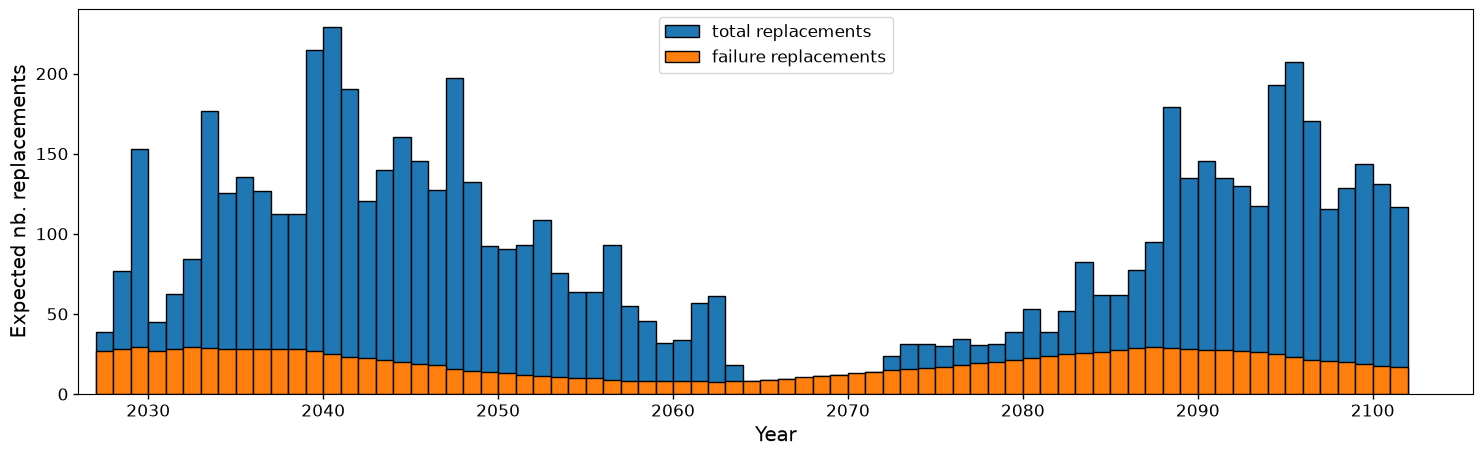

In [25]:
fig, ax = plt.subplots(figsize=(18, 5))
ax.bar(
    timeline + 2026,
    np.sum(nb_replacements, axis=-1),
    align="edge",
    width=1.0,
    label="total replacements",
    edgecolor="black",
)
ax.bar(
    timeline + 2026,
    np.sum(nb_failures, axis=-1),
    align="edge",
    width=1.0,
    label="failure replacements",
    edgecolor="black",
)
ax.set_xlim(left=2026)
ax.set_xlabel("Year", fontsize="x-large")
ax.set_ylabel("Expected nb. replacements", fontsize="x-large")
ax.tick_params(axis="both", labelsize=12, width=1.0)
plt.legend(fontsize="large")
plt.show()

### References

[1] : Gertsbakh, I. (2002). Reliability theory with applications to preventive maintenance. IIE Transactions, 34(12), 1111-1114.

[2] : Park, C. Contemporary Engineering Economics, 6th ed. Pearson, 2016.

[3] : William G. Sullivan, Elin M Wicks et C Patrick Koelling, Engineering Economy. 2009

[4] : Resnick, S. I. (2013). Adventures in stochastic processes. Springer Science & Business Media.

[5] : Aven, T., & Jensen, U. (Eds.). (1999). Stochastic models in reliability. New York, NY: Springer New York.